# 09 - Spectral-radius (VAR-stability) robustness

**Question:** do the headline H1/H2/H3 results survive dropping rolling windows whose
fitted VAR is non-stationary (companion spectral radius **rho >= 1**)?

Step 1 re-fits a bivariate VAR(1) on `[btc_rv, local_vol]` per country-day window. A
window with rho >= 1 is explosive and its generalized FEVD is unreliable. Here we drop
those windows and re-estimate, comparing against an **unfiltered baseline computed in the
same run** (so only the dropped windows differ; the baseline reproduces the frozen
`step2_panel_coefs` exactly).

All heavy computation lives in `src/` (tested) and is read here from parquet:
- `src/spillovers/build_stability.py` -> `gold/spillovers_stability.parquet` (rho per window)
- `src/models/robustness_stability.py` -> filtered coefs + `gold/stability_comparison.parquet`

**Bottom line (see tables below):** the headline share is row-normalized to [0,1], so it is
near-immune to the ~0.1% of explosive windows; H2/H3 are essentially unchanged. The
instability lives in the un-normalized mechanism components, but those are already
winsorized before logging, so the mechanism barely moves either.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

GOLD = Path("../data/parquet/gold")
if not GOLD.exists(): GOLD = Path("data/parquet/gold")

stab  = pd.read_parquet(GOLD/"spillovers_stability.parquet")
spill = pd.read_parquet(GOLD/"spillovers.parquet")
head  = pd.read_parquet(GOLD/"step2_stability_coefs.parquet")    # threshold-tagged (inf=baseline)
mech  = pd.read_parquet(GOLD/"decomp_stability_coefs.parquet")
cmp   = pd.read_parquet(GOLD/"stability_comparison.parquet")     # filtered vs baseline
THR   = 1.0   # primary cut
print("stability rows:", stab.shape, "| thresholds:", sorted(head.threshold.unique(), key=lambda x:(np.isinf(x),x)))

stability rows: (148181, 6) | thresholds: [0.99, 1.0, inf]


## A. Spectral-radius distribution

How often is a window non-stationary, and how extreme do the explosive ones get?

In [2]:
def sr_stats(s):
    s = s.dropna()
    return pd.Series({"n": len(s), "median": s.median(), "p95": s.quantile(.95),
                      "p99": s.quantile(.99), "max": s.max(),
                      "%>=0.99": (s>=0.99).mean()*100, "%>=1": (s>=1).mean()*100})
display(pd.DataFrame({"equity": sr_stats(stab.sr_equity),
                      "fx": sr_stats(stab.sr_fx)}).T.round(3))

,n,median,p95,p99,max,%>=0.99,%>=1
equity,135934.0,0.479,0.677,0.712,5.659,0.10,0.090
fx,138652.0,0.477,0.684,0.734,7469.443,0.15,0.118


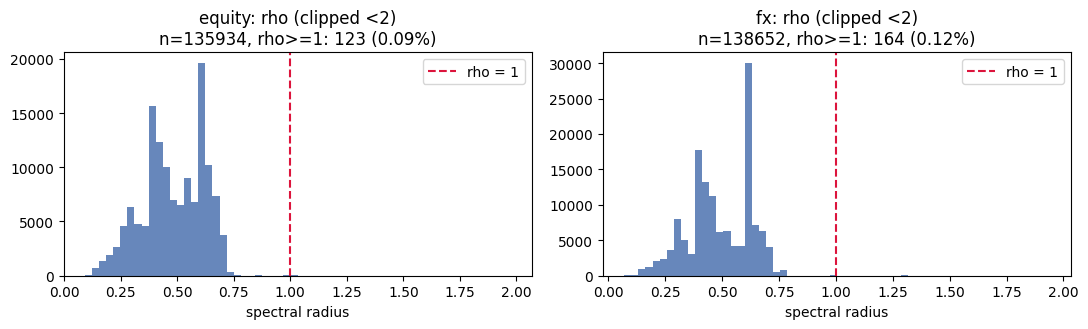

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (chan, col) in zip(axes, [("equity","sr_equity"), ("fx","sr_fx")]):
    s = stab[col].dropna(); z = s[s < 2]
    ax.hist(z, bins=60, color="#4C72B0", alpha=.85)
    ax.axvline(1.0, color="crimson", lw=1.5, ls="--", label="rho = 1")
    n_ex = int((s >= 1).sum())
    ax.set_title(f"{chan}: rho (clipped <2)\nn={s.notna().sum()}, rho>=1: {n_ex} ({n_ex/len(s)*100:.2f}%)")
    ax.set_xlabel("spectral radius"); ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# Most explosive windows (these are the ones the filter removes)
worst = []
for chan, col in [("equity","sr_equity"), ("fx","sr_fx")]:
    w = stab.dropna(subset=[col]).nlargest(5, col)[["country_id","date",col]].rename(columns={col:"rho"})
    w["channel"] = chan; worst.append(w)
display(pd.concat(worst).sort_values("rho", ascending=False)[["channel","country_id","date","rho"]]
        .head(10).reset_index(drop=True).round(2))

/tmp/ipykernel_1505612/3561294122.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .head(10).reset_index(drop=True).round(2))


,channel,country_id,date,rho
0,fx,QAT,2020-11-17,7469.44
1,fx,QAT,2024-05-16,118.81
2,fx,QAT,2021-09-29,76.45
3,fx,LBN,2024-02-21,49.40
4,fx,LBN,2023-02-02,42.73
5,equity,MUS,2020-03-09,5.66
6,equity,CAN,2020-03-09,3.84
7,equity,COL,2020-03-09,3.52
8,equity,JPN,2024-08-05,3.31
9,equity,OMN,2020-03-09,2.70


## B. H1 (descriptive): spillover shares, kept vs dropped

If dropping the explosive windows barely changes the spillover-share distribution, the
descriptive H1 claim (transmission is measurable and time-varying) is unaffected.

In [5]:
m = spill.merge(stab[["date","country_id","sr_equity","sr_fx"]], on=["date","country_id"], how="left")
def share_compare(share_col, sr_col):
    d = m.dropna(subset=[share_col])
    kept = d.loc[d[sr_col] < 1, share_col]
    drop = d.loc[d[sr_col] >= 1, share_col]
    return pd.Series({"n_all": len(d), "mean_all": d[share_col].mean(), "median_all": d[share_col].median(),
                      "n_kept": len(kept), "mean_kept": kept.mean(), "median_kept": kept.median(),
                      "n_dropped": len(drop),
                      "mean_dropped": drop.mean() if len(drop) else np.nan})
display(pd.DataFrame({"equity": share_compare("spill_equity","sr_equity"),
                      "fx": share_compare("spill_fx","sr_fx")}).T.round(4))

,n_all,mean_all,median_all,n_kept,mean_kept,median_kept,n_dropped,mean_dropped
equity,135658.0,0.0525,0.0116,135535.0,0.0524,0.0116,123.0,0.2394
fx,138652.0,0.0243,0.0081,138488.0,0.0240,0.0081,164.0,0.2872


## C. H2 / H3 headline: baseline vs rho < 1

`coef_base` = all windows (reproduces the frozen headline); `coef_rho<1` = explosive windows
dropped. `sign_flip` / `sig_change` flag any qualitative move. Focal terms: H2 = `ci_x_cv`
(openness x crypto), H3 = `errf_x_cv` (float x crypto) and the three-way `ci_x_errf_x_cv`.

In [6]:
def focal_headline(cmp, thr=THR):
    c = cmp[(cmp.family=="headline") & (cmp.threshold==thr)]
    f = c[((c.term=="ci_x_cv") & c.spec.isin(["pooled_full","twfe"])) |
          ((c.term=="errf_x_cv") & c.spec.isin(["fx_h3_direct","fx_h3_direct_net"])) |
          ((c.term=="ci_x_errf_x_cv") & (c.spec=="fx_h3"))]
    cols = ["channel","spec","term","coef_cur","coef_flt","d_coef","pval_cur","pval_flt","d_nobs","sign_flip","sig_change"]
    return (f[cols].rename(columns={"coef_cur":"coef_base","coef_flt":"coef_rho<1",
                                    "pval_cur":"p_base","pval_flt":"p_rho<1"})
            .sort_values(["channel","spec","term"]).reset_index(drop=True))
display(focal_headline(cmp).round(4))

,channel,spec,term,coef_base,coef_rho<1,d_coef,p_base,p_rho<1,d_nobs,sign_flip,sig_change
0,equity,pooled_full,ci_x_cv,-0.0052,-0.0052,-0.0000,0.3789,0.3866,-108,False,False
1,equity,twfe,ci_x_cv,0.0049,0.0049,0.0000,0.3545,0.3508,-114,False,False
2,fx,fx_h3,ci_x_errf_x_cv,0.0008,0.0006,-0.0002,0.7944,0.8338,-136,False,False
3,fx,fx_h3_direct,errf_x_cv,-0.0046,-0.0049,-0.0004,0.1179,0.0736,-136,False,False
4,fx,fx_h3_direct_net,errf_x_cv,-0.0035,-0.0038,-0.0003,0.2141,0.1638,-136,False,False
5,fx,pooled_full,ci_x_cv,-0.0065,-0.0069,-0.0004,0.0153,0.0052,-136,False,False
6,fx,twfe,ci_x_cv,0.0008,0.0006,-0.0002,0.8159,0.8626,-151,False,False


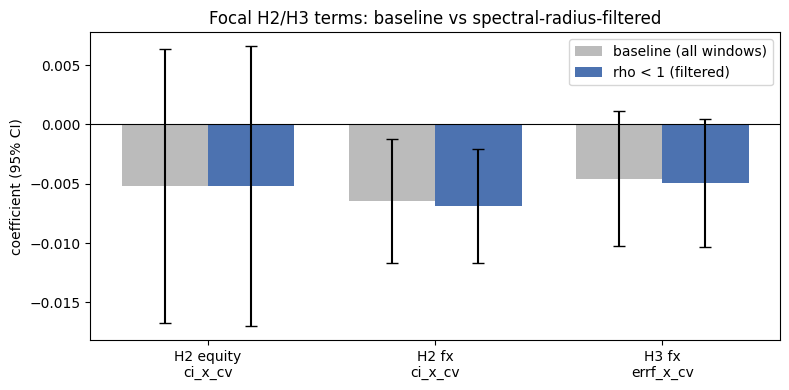

In [7]:
# Focal coefficients with 95% CIs, baseline vs filtered
def coef_se(channel, spec, term, thr):
    r = head[(head.channel==channel)&(head.spec==spec)&(head.term==term)&(head.threshold==thr)]
    return (r.coef.iloc[0], r.se.iloc[0]) if len(r) else (np.nan, np.nan)
focal = [("H2 equity\nci_x_cv","equity","pooled_full","ci_x_cv"),
         ("H2 fx\nci_x_cv","fx","pooled_full","ci_x_cv"),
         ("H3 fx\nerrf_x_cv","fx","fx_h3_direct","errf_x_cv")]
labels, bc, be, fc, fe = [], [], [], [], []
for lab, ch, sp, tm in focal:
    b = coef_se(ch, sp, tm, np.inf); f = coef_se(ch, sp, tm, THR)
    labels.append(lab); bc.append(b[0]); be.append(1.96*b[1]); fc.append(f[0]); fe.append(1.96*f[1])
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x-w/2, bc, w, yerr=be, capsize=4, label="baseline (all windows)", color="#BBBBBB")
ax.bar(x+w/2, fc, w, yerr=fe, capsize=4, label="rho < 1 (filtered)", color="#4C72B0")
ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("coefficient (95% CI)")
ax.set_title("Focal H2/H3 terms: baseline vs spectral-radius-filtered")
ax.legend(); plt.tight_layout(); plt.show()

## D. Mechanism (bivariate decomposition): baseline vs rho < 1

The "bigger pie / variance amplification" story rides the un-normalized components
(`logA` = crypto contribution, `logB` = own-shock contribution, `log_localvar` = total local
variance). This is where rho >= 1 blows up (the 10^64 FX artifact) -- but the decomposition
winsorizes to [1%, 99%] before logging, so those windows were already clipped; the
spectral-radius filter is the principled version of the same exclusion.

In [8]:
mc = cmp[(cmp.family=="mechanism") & (cmp.threshold==THR) & (cmp.term=="ci_x_cv") & (cmp.spec=="pooled_full")]
cols = ["measure","channel","coef_cur","coef_flt","d_coef","pval_cur","pval_flt","d_nobs","sign_flip"]
display(mc[cols].rename(columns={"coef_cur":"coef_base","coef_flt":"coef_rho<1",
                                 "pval_cur":"p_base","pval_flt":"p_rho<1"})
        .sort_values(["measure","channel"]).reset_index(drop=True).round(4))

,measure,channel,coef_base,coef_rho<1,d_coef,p_base,p_rho<1,d_nobs,sign_flip
0,logA,equity,-0.1306,-0.1347,-0.0042,0.3319,0.3189,-108,False
1,logA,fx,-0.3103,-0.3192,-0.0089,0.1101,0.0996,-136,False
2,logB,equity,0.1242,0.1209,-0.0033,0.1313,0.1444,-108,False
3,logB,fx,0.1201,0.1172,-0.0029,0.4669,0.4802,-136,False
4,log_localvar,equity,0.1134,0.1102,-0.0033,0.1827,0.1988,-108,False
5,log_localvar,fx,0.1148,0.1112,-0.0036,0.4855,0.5018,-136,False


## E. Threshold sensitivity

Does the conclusion depend on the exact cut? Compare baseline (all windows), rho < 1, and the
stricter near-unit-root cut rho < 0.99.

In [9]:
rows = []
for lab, ch, sp, tm in [("H2 equity ci_x_cv","equity","pooled_full","ci_x_cv"),
                        ("H2 fx ci_x_cv","fx","pooled_full","ci_x_cv"),
                        ("H3 fx errf_x_cv","fx","fx_h3_direct","errf_x_cv")]:
    for thr in sorted(head.threshold.unique(), key=lambda x:(np.isinf(x), -x)):
        r = head[(head.channel==ch)&(head.spec==sp)&(head.term==tm)&(head.threshold==thr)]
        if len(r):
            cut = "baseline" if np.isinf(thr) else f"rho<{thr:g}"
            rows.append({"term": lab, "cut": cut, "coef": r.coef.iloc[0],
                         "se": r.se.iloc[0], "pval": r.pval.iloc[0], "nobs": int(r.nobs.iloc[0])})
sens = pd.DataFrame(rows)
display(sens.round(4))
print("\nSign flips / significance crossings across ALL terms at rho<1:",
      int(cmp[cmp.threshold==THR].sign_flip.sum()), "/",
      int(cmp[cmp.threshold==THR].sig_change.sum()))

,term,cut,coef,se,pval,nobs
0,H2 equity ci_x_cv,rho<1,-0.0052,0.0060,0.3866,102383
1,H2 equity ci_x_cv,rho<0.99,-0.0052,0.0060,0.3797,102374
2,H2 equity ci_x_cv,baseline,-0.0052,0.0059,0.3789,102491
3,H2 fx ci_x_cv,rho<1,-0.0069,0.0025,0.0052,115737
4,H2 fx ci_x_cv,rho<0.99,-0.0068,0.0025,0.0053,115700
5,H2 fx ci_x_cv,baseline,-0.0065,0.0027,0.0153,115873
6,H3 fx errf_x_cv,rho<1,-0.0049,0.0027,0.0736,115737
7,H3 fx errf_x_cv,rho<0.99,-0.0049,0.0027,0.0752,115700
8,H3 fx errf_x_cv,baseline,-0.0046,0.0029,0.1179,115873



Sign flips / significance crossings across ALL terms at rho<1: 2 / 2


## Conclusion

- **~0.1% of windows are non-stationary** (rho >= 1), with rare extreme outliers (FX max rho in
  the thousands) -- exactly the windows behind the un-normalized FEVD blow-up.
- **H1/H2/H3 are robust.** No focal term flips sign or crosses significance; the H2 FX
  interaction is essentially unchanged (if anything marginally cleaner), H3 stays rejected.
  The only two significance crossings are nuisance controls (`chinn_ito` level, `crypto_ban`)
  sitting exactly at p=0.05 in the float subsample; the two sign flips are coefficients that
  are statistically zero (p ~ 0.95-1.0).
- **The mechanism is robust too**, because the decomposition already winsorizes the explosive
  tails; the spectral-radius filter confirms this with a principled exclusion rather than an
  ad-hoc clip.

This directly answers the `empirical_design.md` caveat that the non-stationary windows might
drive results: they do not.